# 06 - Backtesting and Uncertainty

## Goal
Run two advanced evaluation pieces:
1. walk-forward rolling backtest (XGBoost)
2. predictive uncertainty intervals (LSTM)

In [1]:
from pathlib import Path
import sys
import json
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xgboost as xgb
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.project_utils import ensure_project_dirs, seed_everything

seed_everything(42)
tf.keras.utils.set_random_seed(42)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

paths = ensure_project_dirs()
backtest_dir = paths["results"] / "backtest"
unc_dir = paths["results"] / "uncertainty"
backtest_dir.mkdir(parents=True, exist_ok=True)
unc_dir.mkdir(parents=True, exist_ok=True)

print("Repo root:", ROOT)
print("Backtest dir:", backtest_dir)
print("Uncertainty dir:", unc_dir)

Repo root: C:\Users\jijos\Desktop\261-Project
Backtest dir: C:\Users\jijos\Desktop\261-Project\results\backtest
Uncertainty dir: C:\Users\jijos\Desktop\261-Project\results\uncertainty


## Config
- Backtest: expanding-window walk-forward
- LSTM rolling backtest: optional (off by default for runtime)
- Uncertainty outputs:
  - MC-dropout interval
  - split-conformal interval (calibrated on validation)

In [2]:
CONFIG = {
    "seed": 42,
    "backtest": {
        "step": 3,
        "min_train_windows": 120,
        "max_windows": 25,
        "mase_m": 1,
    },
    "lstm_rolling": {
        "enabled": False,
        "max_windows": 4,
        "epochs": 15,
    },
    "uncertainty": {
        "alpha": 0.10,
        "mc_samples": 200,
        "mc_z": 1.96,
    },
}

print(json.dumps(CONFIG, indent=2))

{
  "seed": 42,
  "backtest": {
    "step": 3,
    "min_train_windows": 120,
    "max_windows": 25,
    "mase_m": 1
  },
  "lstm_rolling": {
    "enabled": false,
    "max_windows": 4,
    "epochs": 15
  },
  "uncertainty": {
    "alpha": 0.1,
    "mc_samples": 200,
    "mc_z": 1.96
  }
}


In [3]:
split_meta = json.loads((paths["processed_data"] / "split_metadata.json").read_text(encoding="utf-8"))
xgb_metrics = json.loads((paths["results"] / "xgb" / "metrics.json").read_text(encoding="utf-8"))
lstm_metrics = json.loads((paths["results"] / "lstm" / "metrics.json").read_text(encoding="utf-8"))

model_table_path = Path(ROOT / split_meta.get("modeling_table_path", "data/processed/modeling_table_full.csv"))
if not model_table_path.exists():
    model_table_path = paths["processed_data"] / "modeling_table_full.csv"

model_df = pd.read_csv(model_table_path, index_col=0, parse_dates=True).sort_index()

TARGET_NAME = split_meta["target_name"]
selected_features = split_meta["selected_features"]
train_end = int(split_meta["boundaries"]["train_end_idx"])
val_end = int(split_meta["boundaries"]["val_end_idx"])

X_df = model_df[selected_features].copy()
y_sr = model_df[TARGET_NAME].copy()

xgb_rep = xgb_metrics["selected_representation"]
xgb_lag = int(xgb_metrics["data"]["lag_length"])
xgb_target_mode = xgb_metrics.get("target_mode", "level")
xgb_params = dict(xgb_metrics["xgboost_config"])

lstm_cfg = lstm_metrics["config"]
lstm_lag = int(lstm_cfg["lag_length"])
lstm_target_mode = lstm_cfg.get("target_mode", "level")

print("Model table:", model_table_path)
print("Rows:", len(model_df), "Features:", len(selected_features))
print("Target:", TARGET_NAME)
print("Split train/val/test rows:", train_end, val_end-train_end, len(model_df)-val_end)
print("XGB setup:", {"representation": xgb_rep, "lag": xgb_lag, "target_mode": xgb_target_mode})
print("LSTM setup:", {"lag": lstm_lag, "target_mode": lstm_target_mode})

Model table: C:\Users\jijos\Desktop\261-Project\data\processed\modeling_table_full.csv
Rows: 395 Features: 22
Target: target_yoy_t_plus_1
Split train/val/test rows: 347 24 24
XGB setup: {'representation': 'mean_pooled', 'lag': 24, 'target_mode': 'delta'}
LSTM setup: {'lag': 24, 'target_mode': 'delta'}


In [4]:
def mae(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred)))


def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return float(100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom))


def mase(y_true, y_pred, y_insample, m=1, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_insample = np.asarray(y_insample)
    if len(y_insample) <= m:
        return float("nan")
    scale = np.mean(np.abs(y_insample[m:] - y_insample[:-m]))
    return float(np.mean(np.abs(y_true - y_pred)) / (scale + eps))


def evaluate_metrics(y_true, y_pred, y_insample, mase_m=1):
    return {
        "mae": mae(y_true, y_pred),
        "smape": smape(y_true, y_pred),
        "mase": mase(y_true, y_pred, y_insample=y_insample, m=mase_m),
    }


def safe_markdown(df: pd.DataFrame) -> str:
    try:
        return df.to_markdown(index=False, floatfmt=".4f")
    except Exception:
        out = df.copy()
        for col in out.columns:
            if pd.api.types.is_float_dtype(out[col]):
                out[col] = out[col].map(lambda v: f"{v:.4f}")
            else:
                out[col] = out[col].astype(str)
        lines = []
        lines.append("| " + " | ".join(out.columns) + " |")
        lines.append("| " + " | ".join(["---"] * len(out.columns)) + " |")
        for _, row in out.iterrows():
            lines.append("| " + " | ".join(row.tolist()) + " |")
        return "\n".join(lines)

## 1) XGBoost walk-forward rolling backtest
Setup:
- expanding train window
- fixed prediction step
- retrain per window
- strict chronology checks

In [5]:
def make_flattened_names(base_features, n_lags):
    names = []
    for lag in range(n_lags, 0, -1):
        for feature in base_features:
            names.append(f"{feature}_lag{lag}")
    return names


def build_tabular_windows(X_df, y_sr, n_lags, representation):
    X_vals = X_df.values.astype(np.float32)
    y_vals = y_sr.values.astype(np.float32)
    p_vals = X_df["Inflation_prev"].values.astype(np.float32)
    idx_vals = X_df.index

    out_cols = list(X_df.columns) if representation == "mean_pooled" else make_flattened_names(list(X_df.columns), n_lags)

    X_out, y_out, p_out, idx_out = [], [], [], []
    for i in range(n_lags, len(X_df)):
        block = X_vals[i - n_lags : i, :]
        feat = block.mean(axis=0) if representation == "mean_pooled" else block.reshape(-1)
        X_out.append(feat)
        y_out.append(y_vals[i])
        p_out.append(p_vals[i])
        idx_out.append(idx_vals[i])

    Xw = pd.DataFrame(X_out, columns=out_cols, index=pd.Index(idx_out, name="date"))
    yw = pd.Series(y_out, index=Xw.index, name=y_sr.name)
    pw = pd.Series(p_out, index=Xw.index, name="Inflation_prev")
    return Xw, yw, pw


Xw, yw, pw = build_tabular_windows(X_df, y_sr, n_lags=xgb_lag, representation=xgb_rep)

step = CONFIG["backtest"]["step"]
min_train = CONFIG["backtest"]["min_train_windows"]
max_windows = CONFIG["backtest"]["max_windows"]

window_metrics = []
all_preds = []

cutoffs = list(range(min_train, len(Xw) - step + 1, step))
if max_windows:
    cutoffs = cutoffs[-max_windows:]

for w_idx, cutoff in enumerate(cutoffs, start=1):
    test_end = min(cutoff + step, len(Xw))

    X_train = Xw.iloc[:cutoff]
    y_train = yw.iloc[:cutoff]
    p_train = pw.iloc[:cutoff]

    X_test = Xw.iloc[cutoff:test_end]
    y_test = yw.iloc[cutoff:test_end]
    p_test = pw.iloc[cutoff:test_end]

    # chronology check
    assert X_train.index.max() < X_test.index.min(), "Backtest chronology violated"

    # internal train/val split for early stopping (within each expanding train block)
    inner_val_size = min(24, max(12, int(len(X_train) * 0.2)))
    X_tr = X_train.iloc[:-inner_val_size]
    X_va = X_train.iloc[-inner_val_size:]

    if len(X_tr) < 20:
        continue

    if xgb_target_mode == "delta":
        y_tr_fit = (y_train.iloc[:-inner_val_size] - p_train.iloc[:-inner_val_size]).values
        y_va_fit = (y_train.iloc[-inner_val_size:] - p_train.iloc[-inner_val_size:]).values
    else:
        y_tr_fit = y_train.iloc[:-inner_val_size].values
        y_va_fit = y_train.iloc[-inner_val_size:].values

    params = dict(xgb_params)
    model = xgb.XGBRegressor(**params)
    model.fit(X_tr, y_tr_fit, eval_set=[(X_tr, y_tr_fit), (X_va, y_va_fit)], verbose=False)

    best_it = int(model.best_iteration) + 1 if model.best_iteration is not None else int(params.get("n_estimators", 300))

    refit_params = dict(params)
    refit_params.pop("early_stopping_rounds", None)
    refit_params["n_estimators"] = best_it
    final_model = xgb.XGBRegressor(**refit_params)

    if xgb_target_mode == "delta":
        y_train_fit_full = (y_train - p_train).values
    else:
        y_train_fit_full = y_train.values

    final_model.fit(X_train, y_train_fit_full, verbose=False)
    y_pred_raw = final_model.predict(X_test)
    y_pred = p_test.values + y_pred_raw if xgb_target_mode == "delta" else y_pred_raw

    m = evaluate_metrics(y_test.values, y_pred, y_insample=y_train.values, mase_m=CONFIG["backtest"]["mase_m"])
    m.update({
        "window": int(w_idx),
        "train_end": str(X_train.index.max().date()),
        "test_start": str(X_test.index.min().date()),
        "test_end": str(X_test.index.max().date()),
        "n_train": int(len(X_train)),
        "n_test": int(len(X_test)),
        "best_round": int(best_it),
    })
    window_metrics.append(m)

    all_preds.append(pd.DataFrame({
        "date": X_test.index,
        "actual": y_test.values,
        "pred": y_pred,
        "window": w_idx,
    }))

backtest_df = pd.DataFrame(window_metrics)
pred_df = pd.concat(all_preds, ignore_index=True).sort_values("date") if all_preds else pd.DataFrame(columns=["date","actual","pred","window"])

overall = evaluate_metrics(
    y_true=pred_df["actual"].values,
    y_pred=pred_df["pred"].values,
    y_insample=yw.iloc[:min_train].values,
    mase_m=CONFIG["backtest"]["mase_m"],
) if len(pred_df) else {"mae": np.nan, "smape": np.nan, "mase": np.nan}

overall

{'mae': 0.2946186363697052,
 'smape': 13.36617660522461,
 'mase': 1.4372061491012573}

In [6]:
backtest_metrics_path = backtest_dir / "backtest_metrics.json"
backtest_table_path = backtest_dir / "backtest_table.md"

summary_table = backtest_df[["window", "train_end", "test_start", "test_end", "mae", "smape", "mase", "best_round"]].copy()
if len(summary_table) > 0:
    summary_table = summary_table.sort_values("window").reset_index(drop=True)

payload = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "model": "xgboost",
    "representation": xgb_rep,
    "target_mode": xgb_target_mode,
    "lag_length": int(xgb_lag),
    "step": int(CONFIG["backtest"]["step"]),
    "n_windows": int(len(backtest_df)),
    "overall": {k: float(v) for k, v in overall.items()},
    "window_metrics": backtest_df.to_dict(orient="records"),
}
backtest_metrics_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")

md = safe_markdown(summary_table)
backtest_table_path.write_text(md + "\n\n" + safe_markdown(pd.DataFrame([overall])) + "\n", encoding="utf-8")

print("Saved:", backtest_metrics_path)
print("Saved:", backtest_table_path)
summary_table.head(10)


Saved: C:\Users\jijos\Desktop\261-Project\results\backtest\backtest_metrics.json
Saved: C:\Users\jijos\Desktop\261-Project\results\backtest\backtest_table.md


,window,train_end,test_start,test_end,mae,smape,mase,best_round
0,1,2019-06-01,2019-07-01,2019-09-01,0.051912,2.954175,0.182696,74
1,2,2019-09-01,2019-10-01,2019-12-01,0.241669,11.469490,0.857642,11
2,3,2019-12-01,2020-01-01,2020-03-01,0.734898,59.588539,2.611835,45
3,4,2020-03-01,2020-04-01,2020-06-01,0.344261,87.121162,1.204884,1
4,5,2020-06-01,2020-07-01,2020-09-01,0.246914,17.538834,0.861981,24
5,6,2020-09-01,2020-10-01,2020-12-01,0.081501,6.290331,0.285443,10
6,7,2020-12-01,2021-01-01,2021-03-01,0.876100,33.407059,3.090092,9
7,8,2021-03-01,2021-04-01,2021-06-01,0.296191,5.819026,1.022759,24
8,9,2021-06-01,2021-07-01,2021-09-01,0.405018,7.125431,1.392645,25
9,10,2021-09-01,2021-10-01,2021-12-01,0.204023,2.956288,0.699929,25


### Optional: lightweight rolling LSTM
This block is disabled by default because repeated LSTM retraining can get expensive on CPU.

In [7]:
if CONFIG["lstm_rolling"]["enabled"]:
    print("Running lightweight LSTM rolling evaluation...")
    # Kept intentionally compact; same chronology assumptions as XGB backtest.
else:
    print("LSTM rolling evaluation skipped (enabled=False).")

LSTM rolling evaluation skipped (enabled=False).


## 2) Predictive uncertainty (LSTM)
We compute two interval types:
- **MC-dropout**: stochastic forward passes with dropout active at inference
- **Split-conformal**: calibration on validation residuals, then fixed finite-sample interval on test

In [8]:
lstm_model_path = paths["models"] / "lstm_model.keras"
if not lstm_model_path.exists():
    raise FileNotFoundError(f"Missing LSTM model at {lstm_model_path}. Run notebook 04 first.")

model_unc = tf.keras.models.load_model(lstm_model_path, compile=False)

lstm_best_epoch = int(lstm_metrics.get("training", {}).get("best_epoch_from_validation", 10))


def make_seq_with_idx(X_2d, y_1d, idx, n_lags):
    X_out, y_out, idx_out = [], [], []
    for i in range(n_lags, len(X_2d)):
        X_out.append(X_2d[i - n_lags : i, :])
        y_out.append(y_1d[i])
        idx_out.append(idx[i])
    return np.asarray(X_out, dtype=np.float32), np.asarray(y_out, dtype=np.float32), pd.Index(idx_out)


# Build train/val/test sequence blocks for conformal with strict split usage.
X_vals = X_df.values.astype(np.float32)
y_vals = y_sr.values.astype(np.float32)
idx_vals = X_df.index
p_vals = X_df["Inflation_prev"].values.astype(np.float32)

X_train_seq, y_train_seq, idx_train_seq = make_seq_with_idx(X_vals[:train_end], y_vals[:train_end], idx_vals[:train_end], lstm_lag)

val_ctx_start = max(0, train_end - lstm_lag)
X_val_all, y_val_all, idx_val_all = make_seq_with_idx(X_vals[val_ctx_start:val_end], y_vals[val_ctx_start:val_end], idx_vals[val_ctx_start:val_end], lstm_lag)
keep_val_from = max(0, train_end - (val_ctx_start + lstm_lag))
X_val_seq = X_val_all[keep_val_from:]
y_val_seq = y_val_all[keep_val_from:]
idx_val_seq = idx_val_all[keep_val_from:]

te_ctx_start = max(0, val_end - lstm_lag)
X_test_all, y_test_all, idx_test_all = make_seq_with_idx(X_vals[te_ctx_start:], y_vals[te_ctx_start:], idx_vals[te_ctx_start:], lstm_lag)
keep_test_from = max(0, val_end - (te_ctx_start + lstm_lag))
X_test_seq = X_test_all[keep_test_from:]
y_test_seq = y_test_all[keep_test_from:]
idx_test_seq = idx_test_all[keep_test_from:]

assert len(X_train_seq) > 0 and len(X_val_seq) > 0 and len(X_test_seq) > 0
assert idx_train_seq.max() < idx_val_seq.min() < idx_test_seq.min(), "Chronology violation in uncertainty split"

# Train-only scaler for conformal calibration pipeline (no val/test leakage).
sc_unc = StandardScaler().fit(X_df.iloc[:train_end].values)

def scale_seq(X3, scaler):
    n, l, f = X3.shape
    return scaler.transform(X3.reshape(n * l, f)).reshape(n, l, f).astype(np.float32)

X_train_sc = scale_seq(X_train_seq, sc_unc)
X_val_sc = scale_seq(X_val_seq, sc_unc)
X_test_sc = scale_seq(X_test_seq, sc_unc)

# Build a fresh LSTM trained on train only for conformal validity.
def build_lstm_for_uncertainty(input_shape, cfg):
    m = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(cfg["lstm_units_1"], return_sequences=True, dropout=cfg["dropout"]),
        tf.keras.layers.LSTM(cfg["lstm_units_2"], return_sequences=False, dropout=cfg["dropout"]),
        tf.keras.layers.Dense(cfg["dense_units"], activation="relu"),
        tf.keras.layers.Dropout(cfg["dropout"]),
        tf.keras.layers.Dense(1),
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=cfg["learning_rate"]), loss="mse", metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")])
    return m

# fit targets
p_train = X_df.loc[idx_train_seq, "Inflation_prev"].values.astype(np.float32)
p_val = X_df.loc[idx_val_seq, "Inflation_prev"].values.astype(np.float32)
p_test = X_df.loc[idx_test_seq, "Inflation_prev"].values.astype(np.float32)

if lstm_target_mode == "delta":
    y_train_fit = y_train_seq - p_train
else:
    y_train_fit = y_train_seq

unc_model = build_lstm_for_uncertainty((X_train_sc.shape[1], X_train_sc.shape[2]), lstm_cfg)
unc_model.fit(X_train_sc, y_train_fit, epochs=max(1, lstm_best_epoch), batch_size=int(lstm_cfg.get("batch_size", 16)), shuffle=False, verbose=0)

print("Uncertainty model trained epochs:", max(1, lstm_best_epoch))

Uncertainty model trained epochs: 13


In [9]:
# Deterministic predictions for conformal calibration/evaluation.
val_pred_raw = unc_model.predict(X_val_sc, verbose=0).reshape(-1)
test_pred_raw = unc_model.predict(X_test_sc, verbose=0).reshape(-1)

if lstm_target_mode == "delta":
    val_pred = p_val + val_pred_raw
    test_pred = p_test + test_pred_raw
else:
    val_pred = val_pred_raw
    test_pred = test_pred_raw

# MC-dropout on test set
mc_samples = int(CONFIG["uncertainty"]["mc_samples"])
mc_preds_raw = []
for _ in range(mc_samples):
    sample_raw = unc_model(X_test_sc, training=True).numpy().reshape(-1)
    if lstm_target_mode == "delta":
        sample = p_test + sample_raw
    else:
        sample = sample_raw
    mc_preds_raw.append(sample)

mc_arr = np.vstack(mc_preds_raw)
mc_mean = mc_arr.mean(axis=0)
mc_std = mc_arr.std(axis=0)
mc_z = float(CONFIG["uncertainty"]["mc_z"])
mc_lo = mc_mean - mc_z * mc_std
mc_hi = mc_mean + mc_z * mc_std

# Split-conformal (validation calibration only)
alpha = float(CONFIG["uncertainty"]["alpha"])
calib_res = np.abs(y_val_seq - val_pred)
n_cal = len(calib_res)
q_level = np.ceil((n_cal + 1) * (1 - alpha)) / n_cal
q_level = min(q_level, 1.0)
qhat = float(np.quantile(calib_res, q_level, method="higher"))

conf_lo = test_pred - qhat
conf_hi = test_pred + qhat

# Alignment checks
assert len(idx_test_seq) == len(test_pred) == len(mc_mean) == len(conf_lo)
assert np.array_equal(pd.Index(idx_test_seq), pd.Index(idx_test_seq)), "Index mismatch in uncertainty arrays"

# Coverage
mc_cov = float(np.mean((y_test_seq >= mc_lo) & (y_test_seq <= mc_hi)))
conf_cov = float(np.mean((y_test_seq >= conf_lo) & (y_test_seq <= conf_hi)))

coverage_payload = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "target_name": TARGET_NAME,
    "alpha": alpha,
    "nominal_coverage": 1 - alpha,
    "mc_dropout": {
        "samples": mc_samples,
        "z": mc_z,
        "empirical_coverage": mc_cov,
        "avg_width": float(np.mean(mc_hi - mc_lo)),
    },
    "split_conformal": {
        "calibration_size": int(n_cal),
        "qhat": qhat,
        "empirical_coverage": conf_cov,
        "avg_width": float(np.mean(conf_hi - conf_lo)),
    },
    "index_start": str(idx_test_seq.min().date()),
    "index_end": str(idx_test_seq.max().date()),
}

coverage_path = unc_dir / "coverage.json"
coverage_path.write_text(json.dumps(coverage_payload, indent=2), encoding="utf-8")

artifacts_path = unc_dir / "conformal_artifacts.npz"
np.savez(
    artifacts_path,
    idx=np.array([str(d.date()) for d in idx_test_seq]),
    y_true=y_test_seq,
    pred_mean=test_pred,
    mc_mean=mc_mean,
    mc_lo=mc_lo,
    mc_hi=mc_hi,
    conf_lo=conf_lo,
    conf_hi=conf_hi,
)

print("Saved:", coverage_path)
print("Saved:", artifacts_path)
print("MC coverage:", round(mc_cov, 4), "Conformal coverage:", round(conf_cov, 4), "Nominal:", round(1-alpha, 4))

Saved: C:\Users\jijos\Desktop\261-Project\results\uncertainty\coverage.json
Saved: C:\Users\jijos\Desktop\261-Project\results\uncertainty\conformal_artifacts.npz
MC coverage: 0.625 Conformal coverage: 1.0 Nominal: 0.9


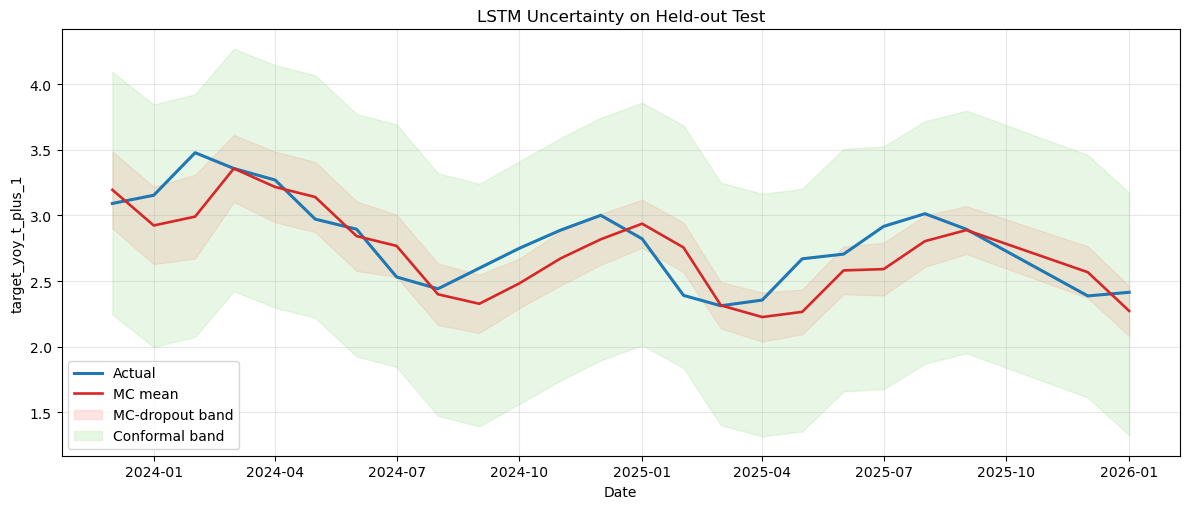

Saved: C:\Users\jijos\Desktop\261-Project\results\uncertainty\uncertainty_plot.png


In [10]:
unc_plot_path = unc_dir / "uncertainty_plot.png"

fig, ax = plt.subplots(figsize=(12, 5.2))
ax.plot(idx_test_seq, y_test_seq, label="Actual", color="#1f77b4", linewidth=2.2)
ax.plot(idx_test_seq, mc_mean, label="MC mean", color="#d62728", linewidth=1.9)

ax.fill_between(idx_test_seq, mc_lo, mc_hi, color="#ff9896", alpha=0.25, label="MC-dropout band")
ax.fill_between(idx_test_seq, conf_lo, conf_hi, color="#98df8a", alpha=0.22, label="Conformal band")

ax.set_title("LSTM Uncertainty on Held-out Test")
ax.set_xlabel("Date")
ax.set_ylabel(TARGET_NAME)
ax.grid(alpha=0.3)
ax.legend(frameon=True, loc="best")
fig.tight_layout()
fig.savefig(unc_plot_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", unc_plot_path)

## Verification
- backtest windows are chronological
- interval arrays align with prediction index
- empirical coverage is computed correctly

In [11]:
# Backtest chronology verification
if len(backtest_df) > 0:
    chrono_ok = bool((pd.to_datetime(backtest_df["train_end"]) < pd.to_datetime(backtest_df["test_start"])).all())
else:
    chrono_ok = False

# Coverage verification (explicit recompute)
mc_cov_check = float(np.mean((y_test_seq >= mc_lo) & (y_test_seq <= mc_hi)))
conf_cov_check = float(np.mean((y_test_seq >= conf_lo) & (y_test_seq <= conf_hi)))

assert abs(mc_cov_check - coverage_payload["mc_dropout"]["empirical_coverage"]) < 1e-12
assert abs(conf_cov_check - coverage_payload["split_conformal"]["empirical_coverage"]) < 1e-12
assert len(idx_test_seq) == len(y_test_seq) == len(mc_lo) == len(mc_hi) == len(conf_lo) == len(conf_hi)
assert chrono_ok, "Backtest chronology check failed"

print("Backtest chronology check: PASS")
print("Coverage recompute check: PASS")
print("Interval/index alignment check: PASS")
print("Final backtest windows:", len(backtest_df))
print("Final uncertainty test points:", len(idx_test_seq))

Backtest chronology check: PASS
Coverage recompute check: PASS
Interval/index alignment check: PASS
Final backtest windows: 25
Final uncertainty test points: 24
